In [80]:
import warnings
warnings.filterwarnings("ignore")

## Imports

In [81]:
import math
import os
import time
import requests
import pandas as pd
import json
import numpy as np
from pathlib import Path
from typing import Optional, Dict, List, Union
from unidecode import unidecode
import matplotlib.pyplot as plt
import seaborn as sns

import pandas_gbq
from google.auth import default
from google.cloud import bigquery
from google.api_core.exceptions import NotFound

In [82]:
BASE_DIR = Path("data")
RAW_DIR = BASE_DIR / "raw"
TRUSTED_DIR = BASE_DIR / "trusted"
ANALYTICS_DIR = BASE_DIR / "analytics"

for path in [RAW_DIR, TRUSTED_DIR, ANALYTICS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

## Bases

In [83]:
project_id = 'loft-dl-datascience'

query_city = '''
select * from loft-dl-datascience.ds_risk_cp.blend3_2__variavel_cidade
'''

df_city = pd.read_gbq(query_city, project_id=project_id)
df_city

,mes_referencia,id_cidade_ibge,city_pc4_mais_100_contratos__pc_categorias
0,2025-12-01,3522307,0.028125
1,2025-12-01,5003702,0.030303
2,2025-12-01,4216206,0.033113
3,2025-12-01,5008305,0.036496
4,2025-12-01,3500105,0.039216
...,...,...,...
1709,2026-08-01,3533908,0.180328
1710,2026-08-01,3122306,0.183087
1711,2026-08-01,2800308,0.204589
1712,2026-08-01,4313300,0.207407


In [84]:
df_city[df_city["id_cidade_ibge"] == 3143302]

,mes_referencia,id_cidade_ibge,city_pc4_mais_100_contratos__pc_categorias
17,2025-12-01,3143302,0.056872
193,2026-01-01,3143302,0.045455
373,2026-02-01,3143302,0.026786
558,2026-03-01,3143302,0.017391
751,2026-04-01,3143302,0.029536
949,2026-05-01,3143302,0.042471
1143,2026-06-01,3143302,0.045082
1337,2026-07-01,3143302,0.048035
1565,2026-08-01,3143302,0.072464


In [85]:
project_id = 'loft-dl-datascience'

query_agency = '''
select * from loft-dl-datascience.ds_risk_cp.blend3_2__variavel_imobiliaria
'''

df_agency = pd.read_gbq(query_agency, project_id=project_id)
df_agency

,mes_referencia,agency_id,agency_pc4_mais_100_contratos__pc_categorias
0,2025-12-01,9706,0.019417
1,2025-12-01,1399,0.021429
2,2025-12-01,4420,0.024390
3,2025-12-01,4926,0.026738
4,2025-12-01,9418,0.028571
...,...,...,...
1284,2026-08-01,10433,0.282258
1285,2026-08-01,592,0.294521
1286,2026-08-01,25913,0.300699
1287,2026-08-01,3419,0.318182


In [86]:
df_agency[df_agency["agency_id"] == 3143302]

,mes_referencia,agency_id,agency_pc4_mais_100_contratos__pc_categorias


## Estatísticas por safra

Média, p25, p50 e p75 de `city_pc4_mais_100_contratos__pc_categorias` (`df_city`) e `agency_pc4_mais_100_contratos__pc_categorias` (`df_agency`), agregadas por `mes_referencia`.

In [87]:
def stats_by_safra(df: pd.DataFrame, value_col: str, date_col: str = "mes_referencia") -> pd.DataFrame:
    """Aggregate mean, p25, p50 and p75 of value_col by safra."""
    out = (
        df.groupby(date_col, as_index=False)[value_col]
        .agg(
            n="count",
            mean="mean",
            p25=lambda s: s.quantile(0.25),
            p50=lambda s: s.quantile(0.50),
            p75=lambda s: s.quantile(0.75),
        )
        .sort_values(date_col)
    )
    out["safra"] = pd.to_datetime(out[date_col]).dt.strftime("%Y-%m")
    return out


def plot_stats_by_safra(stats: pd.DataFrame, title: str, ylabel: str) -> None:
    fig, ax = plt.subplots(figsize=(12, 6))
    styles = {
        "mean": {"marker": "D", "linestyle": "-", "linewidth": 2},
        "p25": {"marker": "v", "linestyle": "--", "linewidth": 1.5},
        "p50": {"marker": "o", "linestyle": "-", "linewidth": 2},
        "p75": {"marker": "^", "linestyle": "--", "linewidth": 1.5},
    }
    for metric, style in styles.items():
        ax.plot(stats["safra"], stats[metric], label=metric, **style)
    ax.set_title(title)
    ax.set_xlabel("Safra")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()


city_stats = stats_by_safra(df_city, "city_pc4_mais_100_contratos__pc_categorias")
agency_stats = stats_by_safra(df_agency, "agency_pc4_mais_100_contratos__pc_categorias")

In [88]:
city_stats

,mes_referencia,n,mean,p25,p50,p75,safra
0,2025-12-01,182,0.113991,0.084811,0.110674,0.142813,2025-12
1,2026-01-01,186,0.110378,0.077820,0.106742,0.141045,2026-01
2,2026-02-01,188,0.105845,0.074418,0.101955,0.136141,2026-02
3,2026-03-01,191,0.100064,0.070836,0.094276,0.125821,2026-03
4,2026-04-01,194,0.096755,0.068031,0.091877,0.119387,2026-04
5,2026-05-01,192,0.095411,0.068162,0.090008,0.118964,2026-05
6,2026-06-01,195,0.094757,0.068627,0.090726,0.117189,2026-06
7,2026-07-01,194,0.096450,0.071429,0.088791,0.118861,2026-07
8,2026-08-01,192,0.098622,0.075289,0.092435,0.120562,2026-08


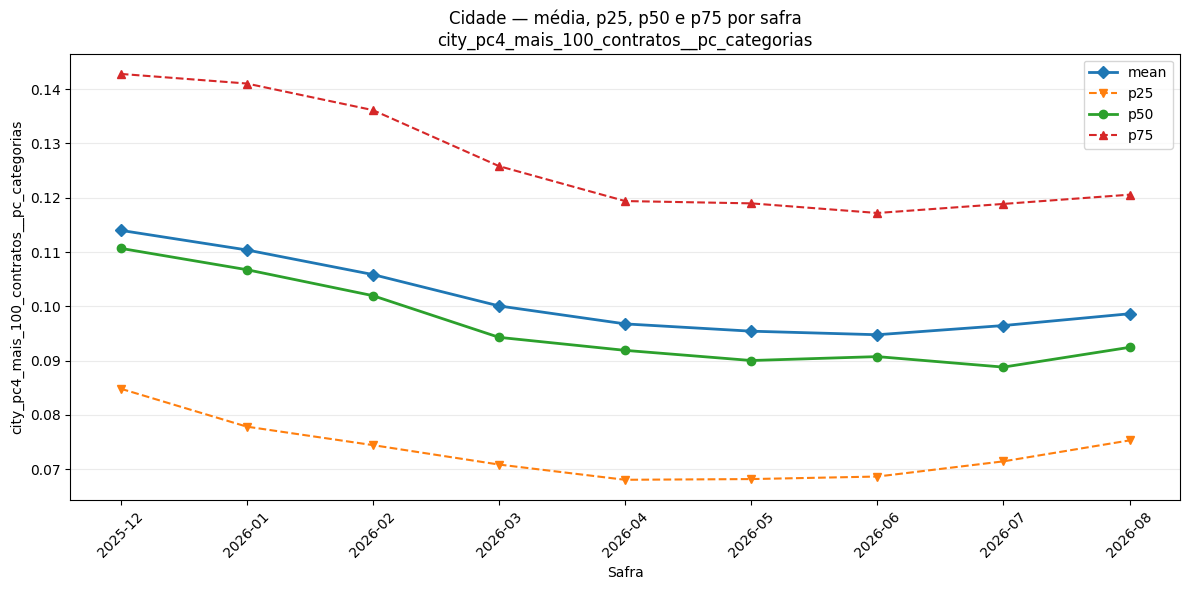

In [89]:
plot_stats_by_safra(
    city_stats,
    title="Cidade — média, p25, p50 e p75 por safra\ncity_pc4_mais_100_contratos__pc_categorias",
    ylabel="city_pc4_mais_100_contratos__pc_categorias",
)

In [90]:
agency_stats

,mes_referencia,n,mean,p25,p50,p75,safra
0,2025-12-01,129,0.143696,0.083333,0.127389,0.187970,2025-12
1,2026-01-01,133,0.141064,0.089744,0.133803,0.189655,2026-01
2,2026-02-01,146,0.133489,0.084306,0.119689,0.169487,2026-02
3,2026-03-01,149,0.124509,0.083067,0.120536,0.156522,2026-03
4,2026-04-01,154,0.125283,0.080270,0.116026,0.159352,2026-04
5,2026-05-01,150,0.125534,0.079277,0.117698,0.156477,2026-05
6,2026-06-01,151,0.124055,0.080190,0.110818,0.155953,2026-06
7,2026-07-01,143,0.126476,0.080770,0.113043,0.159630,2026-07
8,2026-08-01,134,0.132397,0.090350,0.122436,0.162220,2026-08


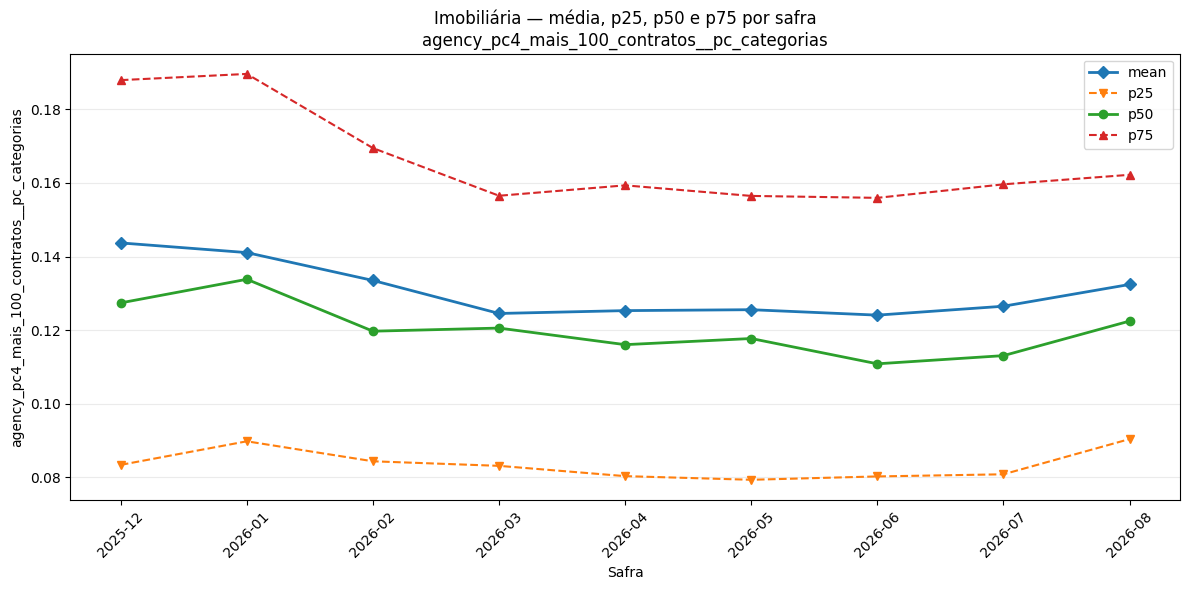

In [91]:
plot_stats_by_safra(
    agency_stats,
    title="Imobiliária — média, p25, p50 e p75 por safra\nagency_pc4_mais_100_contratos__pc_categorias",
    ylabel="agency_pc4_mais_100_contratos__pc_categorias",
)

## Acompanhamento Cidades/Imobiliária por safra

Todas as cidades (`id_cidade_ibge`) e imobiliárias (`agency_id`) nas linhas, `mes_referencia` nas colunas e o valor de `city_pc4_mais_100_contratos__pc_categorias` / `agency_pc4_mais_100_contratos__pc_categorias`. Se a entidade não estiver na base daquela safra, o valor fica nulo.

In [92]:
def pivot_pc_by_safra(
    df: pd.DataFrame,
    entity_col: str,
    value_col: str,
    date_col: str = "mes_referencia",
) -> pd.DataFrame:
    """Pivot PC value by entity (rows) and mes_referencia (columns). Missing safras stay as NaN."""
    aux = df[[date_col, entity_col, value_col]].copy()
    aux[date_col] = pd.to_datetime(aux[date_col]).dt.strftime("%Y-%m-%d")
    table = aux.pivot_table(
        index=entity_col,
        columns=date_col,
        values=value_col,
        aggfunc="first",
    )
    table = table.reindex(sorted(table.columns), axis=1)
    table = table.sort_index()
    return table


city_pc_by_safra = pivot_pc_by_safra(
    df_city,
    entity_col="id_cidade_ibge",
    value_col="city_pc4_mais_100_contratos__pc_categorias",
)
agency_pc_by_safra = pivot_pc_by_safra(
    df_agency,
    entity_col="agency_id",
    value_col="agency_pc4_mais_100_contratos__pc_categorias",
)

In [93]:
city_pc_by_safra

mes_referencia,2025-12-01,2026-01-01,2026-02-01,2026-03-01,2026-04-01,2026-05-01,2026-06-01,2026-07-01,2026-08-01
id_cidade_ibge,,,,,,,,,
2211001,0.126582,0.117207,0.118765,0.136709,0.146154,0.144638,0.155440,0.167109,0.164306
2304400,0.150086,0.163336,0.158918,0.144748,0.142230,0.135088,0.136444,0.123300,0.125828
2403251,0.141593,0.127451,NaN,0.096154,NaN,NaN,NaN,0.077670,0.085714
2408102,0.146444,0.134783,0.128099,0.114537,0.114679,0.099099,0.115880,0.094828,0.095455
2507507,0.092025,0.077381,0.071856,0.064935,0.036496,0.030534,0.031250,0.017544,0.027523
...,...,...,...,...,...,...,...,...,...
5208707,0.169118,0.162176,0.158649,0.158972,0.160108,0.160000,0.165885,0.172243,0.178474
5211503,NaN,NaN,NaN,NaN,NaN,0.145455,0.141593,0.146789,0.145455
5211909,0.066667,0.076923,0.065041,0.078261,0.064220,0.048077,0.076923,0.096154,0.104348


In [94]:
agency_pc_by_safra

mes_referencia,2025-12-01,2026-01-01,2026-02-01,2026-03-01,2026-04-01,2026-05-01,2026-06-01,2026-07-01,2026-08-01
agency_id,,,,,,,,,
81,0.068421,0.062827,0.061224,0.065217,0.069182,0.101911,0.113772,0.129032,0.121429
121,NaN,NaN,NaN,0.240741,0.220183,0.191667,0.172131,0.172131,0.185484
128,0.142157,0.142132,0.117347,0.091892,0.114458,0.103226,0.098039,0.087248,0.101351
215,0.186747,0.176471,0.175227,0.163580,0.163934,0.161491,0.178914,0.200000,0.212329
222,NaN,NaN,0.053097,0.039062,0.045802,0.055556,0.079646,0.076271,NaN
...,...,...,...,...,...,...,...,...,...
38518,NaN,NaN,NaN,NaN,0.192661,0.201613,0.210526,0.192857,0.201342
40682,0.192825,0.205882,0.211538,0.212963,0.211940,0.211538,0.217822,0.195312,0.183406
44081,0.473214,0.441667,0.437500,NaN,NaN,NaN,NaN,NaN,NaN


In [95]:
def month_over_month_variation(table: pd.DataFrame) -> pd.DataFrame:
    """Absolute month-over-month change (current - previous). Missing months stay as NaN."""
    variation = table.diff(axis=1)
    variation = variation.iloc[:, 1:]
    variation.columns = [
        f"{prev} → {curr}"
        for prev, curr in zip(table.columns[:-1], table.columns[1:])
    ]
    return variation

city_pc_mom = month_over_month_variation(city_pc_by_safra)
agency_pc_mom = month_over_month_variation(agency_pc_by_safra)

In [96]:
print("Cidades — variação mês a mês (pp)")
city_pc_mom

Cidades — variação mês a mês (pp)


,2025-12-01 → 2026-01-01,2026-01-01 → 2026-02-01,2026-02-01 → 2026-03-01,2026-03-01 → 2026-04-01,2026-04-01 → 2026-05-01,2026-05-01 → 2026-06-01,2026-06-01 → 2026-07-01,2026-07-01 → 2026-08-01
id_cidade_ibge,,,,,,,,
2211001,-0.009375,0.001558,0.017944,0.009445,-0.001515,0.010802,0.011668,-0.002803
2304400,0.013250,-0.004418,-0.014170,-0.002518,-0.007142,0.001356,-0.013144,0.002528
2403251,-0.014142,NaN,NaN,NaN,NaN,NaN,NaN,0.008044
2408102,-0.011661,-0.006683,-0.013562,0.000141,-0.015580,0.016781,-0.021052,0.000627
2507507,-0.014644,-0.005525,-0.006921,-0.028439,-0.005962,0.000716,-0.013706,0.009979
...,...,...,...,...,...,...,...,...
5208707,-0.006941,-0.003527,0.000323,0.001136,-0.000108,0.005885,0.006358,0.006231
5211503,NaN,NaN,NaN,NaN,NaN,-0.003862,0.005196,-0.001334
5211909,0.010256,-0.011882,0.013220,-0.014041,-0.016143,0.028846,0.019231,0.008194


In [97]:
print("Imobiliárias — variação mês a mês (pp)")
agency_pc_mom

Imobiliárias — variação mês a mês (pp)


,2025-12-01 → 2026-01-01,2026-01-01 → 2026-02-01,2026-02-01 → 2026-03-01,2026-03-01 → 2026-04-01,2026-04-01 → 2026-05-01,2026-05-01 → 2026-06-01,2026-06-01 → 2026-07-01,2026-07-01 → 2026-08-01
agency_id,,,,,,,,
81,-0.005594,-0.001603,0.003993,0.003965,0.032728,0.011862,0.015260,-0.007604
121,NaN,NaN,NaN,-0.020557,-0.028517,-0.019536,0.000000,0.013353
128,-0.000025,-0.024785,-0.025455,0.022566,-0.011232,-0.005187,-0.010791,0.014103
215,-0.010276,-0.001244,-0.011646,0.000354,-0.002444,0.017423,0.021086,0.012329
222,NaN,NaN,-0.014035,0.006739,0.009754,0.024090,-0.003375,NaN
...,...,...,...,...,...,...,...,...
38518,NaN,NaN,NaN,NaN,0.008952,0.008913,-0.017669,0.008485
40682,0.013057,0.005656,0.001424,-0.001023,-0.000402,0.006283,-0.022509,-0.011906
44081,-0.031548,-0.004167,NaN,NaN,NaN,NaN,NaN,NaN


In [98]:
def rank_mom(mom: pd.DataFrame, entity_name: str, n: int = 15) -> pd.DataFrame:
    long = (
        mom.stack(dropna=True)
        .rename("variacao")
        .rename_axis([entity_name, "periodo"])
        .reset_index()
    )
    long["abs_variacao"] = long["variacao"].abs()

    top_abs = long.nlargest(n, "abs_variacao")
    top_up = long.nlargest(n, "variacao")
    top_down = long.nsmallest(n, "variacao")

    latest_col = mom.columns[-1]
    latest = (
        mom[[latest_col]]
        .dropna()
        .rename(columns={latest_col: "variacao"})
        .assign(periodo=latest_col, abs_variacao=lambda d: d["variacao"].abs())
        .reset_index()
        .nlargest(n, "abs_variacao")
    )
    return top_abs, top_up, top_down, latest


city_top_abs, city_top_up, city_top_down, city_latest = rank_mom(city_pc_mom, "id_cidade_ibge")
agency_top_abs, agency_top_up, agency_top_down, agency_latest = rank_mom(agency_pc_mom, "agency_id")

print("Cidades — maiores |variações|")
display(city_top_abs)
print("Cidades — maiores altas")
display(city_top_up)
print("Cidades — maiores quedas")
display(city_top_down)

print("Imobs — maiores |variações|")
display(agency_top_abs)
print("Imobs — maiores altas")
display(agency_top_up)
print("Imobs — maiores quedas")
display(agency_top_down)

Cidades — maiores |variações|


,id_cidade_ibge,periodo,variacao,abs_variacao
51,2927408,2025-12-01 → 2026-01-01,-0.051933,0.051933
54,2927408,2026-03-01 → 2026-04-01,-0.049893,0.049893
153,3138203,2026-02-01 → 2026-03-01,-0.048906,0.048906
52,2927408,2026-01-01 → 2026-02-01,-0.047401,0.047401
323,3502101,2026-02-01 → 2026-03-01,-0.047273,0.047273
361,3505500,2026-01-01 → 2026-02-01,-0.043613,0.043613
1185,4303103,2026-07-01 → 2026-08-01,-0.043522,0.043522
253,3302700,2026-04-01 → 2026-05-01,-0.042944,0.042944
557,3530508,2026-04-01 → 2026-05-01,-0.042255,0.042255
70,3101607,2026-04-01 → 2026-05-01,0.041747,0.041747


Cidades — maiores altas


,id_cidade_ibge,periodo,variacao,abs_variacao
70,3101607,2026-04-01 → 2026-05-01,0.041747,0.041747
1290,4313375,2026-01-01 → 2026-02-01,0.037037,0.037037
965,4202305,2026-06-01 → 2026-07-01,0.036507,0.036507
1485,5218805,2025-12-01 → 2026-01-01,0.034358,0.034358
1365,4318002,2026-03-01 → 2026-04-01,0.033049,0.033049
413,3511508,2026-01-01 → 2026-02-01,0.032629,0.032629
151,3138203,2025-12-01 → 2026-01-01,0.032321,0.032321
125,3129806,2026-06-01 → 2026-07-01,0.030781,0.030781
1282,4313300,2026-01-01 → 2026-02-01,0.030666,0.030666
494,3524303,2026-05-01 → 2026-06-01,0.030191,0.030191


Cidades — maiores quedas


...

,agency_id,periodo,variacao,abs_variacao
518,2874,2026-05-01 → 2026-06-01,0.074345,0.074345
347,1752,2026-01-01 → 2026-02-01,-0.071473,0.071473
118,620,2026-02-01 → 2026-03-01,0.065789,0.065789
820,10037,2026-02-01 → 2026-03-01,0.063187,0.063187
115,592,2026-07-01 → 2026-08-01,0.061644,0.061644
133,641,2026-05-01 → 2026-06-01,-0.057250,0.057250
966,17378,2025-12-01 → 2026-01-01,-0.055143,0.055143
933,13858,2026-01-01 → 2026-02-01,0.054807,0.054807
351,1752,2026-05-01 → 2026-06-01,0.052570,0.052570
205,939,2025-12-01 → 2026-01-01,0.052251,0.052251


Imobs — maiores altas


,agency_id,periodo,variacao,abs_variacao
518,2874,2026-05-01 → 2026-06-01,0.074345,0.074345
118,620,2026-02-01 → 2026-03-01,0.065789,0.065789
820,10037,2026-02-01 → 2026-03-01,0.063187,0.063187
115,592,2026-07-01 → 2026-08-01,0.061644,0.061644
933,13858,2026-01-01 → 2026-02-01,0.054807,0.054807
351,1752,2026-05-01 → 2026-06-01,0.052570,0.052570
205,939,2025-12-01 → 2026-01-01,0.052251,0.052251
45,315,2026-03-01 → 2026-04-01,0.046799,0.046799
728,6882,2026-03-01 → 2026-04-01,0.045233,0.045233
363,1885,2026-04-01 → 2026-05-01,0.042938,0.042938


Imobs — maiores quedas


,agency_id,periodo,variacao,abs_variacao
347,1752,2026-01-01 → 2026-02-01,-0.071473,0.071473
133,641,2026-05-01 → 2026-06-01,-0.057250,0.057250
966,17378,2025-12-01 → 2026-01-01,-0.055143,0.055143
348,1752,2026-02-01 → 2026-03-01,-0.052066,0.052066
882,11913,2026-05-01 → 2026-06-01,-0.050012,0.050012
863,11574,2026-01-01 → 2026-02-01,-0.049797,0.049797
967,17378,2026-01-01 → 2026-02-01,-0.049648,0.049648
558,3419,2026-03-01 → 2026-04-01,-0.048305,0.048305
458,2651,2026-02-01 → 2026-03-01,-0.047500,0.047500
825,10054,2025-12-01 → 2026-01-01,-0.046570,0.046570


## Funil por cidade e imobiliária

Agregação de `df_funil` em `df_funil_city` e `df_funil_agency` (leads, propostas, aprovações, ativações e mix de modelo). O funil desta base cobre jul–ago/2026; o PC cobre dez/2025–ago/2026. O volume do funil entra como peso de relevância na análise de variação.

In [99]:
df_funil = pd.read_parquet(ANALYTICS_DIR / "df_model_simulacao_blend.parquet")
df_funil["mes_referencia"] = df_funil["requested_at"].astype(str).str[:7] + "-01"
df_funil

,contract_id,requested_at,tipo,tipo_contrato,rule,bureau_nm,modeloBlend,approved_products,flag_pop32,product_nm,...,request,_sdc_received_at,_sdc_sequence,documento,rating,_sdc_batched_at,data,result,cr_blendRegressaoPredict,mes_referencia
0,4322310,2026-07-02,PF,PF,BLEND_REGRESSAO_2026,BLEND_REGRESSAO_2026,BLEND_REGRESSAO_2026,[],0,None,...,"{""valor_aluguel"":3500,""matchmaking_on"":false,""...",2026-08-13 19:38:27+00:00,1786649903277863868,86447114900,C,2026-08-13 19:42:18.044000+00:00,2026-07-02 09:08:21+00:00,REPROVAR,0.0937,2026-07-01
1,4324039,2026-07-02,PF,PF,BLEND_HVA3_BVS,HVA3,BLEND3_3,"[25,26,18,20,33,34,35,36,38,39]",0,None,...,"{""valor_aluguel"":2050,""matchmaking_on"":false,""...",2026-08-13 19:38:27+00:00,1786649903620829552,34393575890,A,2026-08-13 19:42:18.942000+00:00,2026-07-02 12:05:12+00:00,APROVAR,NaN,2026-07-01
2,4323023,2026-07-02,PF,PF,BLEND_REGRESSAO_2026,BLEND_REGRESSAO_2026,BLEND_REGRESSAO_2026,"[25,26,18,20,33,34,35,36,38,40]",0,Flex,...,"{""valor_aluguel"":1650,""matchmaking_on"":false,""...",2026-08-13 19:38:27+00:00,1786649903398030855,04483937006,D,2026-08-13 19:42:18.419000+00:00,2026-07-02 10:23:40+00:00,APROVAR,0.2229,2026-07-01
3,4326992,2026-07-02,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,"[25,26,18,20,33,34,35,36,38,41]",0,Smart Plus,...,"{""valor_aluguel"":5000,""matchmaking_on"":false,""...",2026-08-13 19:38:31+00:00,1786649907202943167,22048524818,C,2026-08-13 19:42:18.237000+00:00,2026-07-08 10:38:34+00:00,APROVAR,547.0000,2026-07-01
4,4394604,2026-07-20,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,"[25,26,18,20,33,34,35,36,38]",0,None,...,"{""valor_aluguel"":1700,""matchmaking_on"":false,""...",2026-08-13 19:38:40+00:00,1786649914992635790,05916879920,D,2026-08-13 19:42:18.442000+00:00,2026-07-20 14:08:31+00:00,APROVAR,398.0000,2026-07-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201337,4441019,2026-07-30,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,[],0,None,...,"{""valor_aluguel"":3700,""matchmaking_on"":false,""...",2026-08-13 19:38:43+00:00,1786649921510136636,57899088100,E,2026-08-13 19:42:31.081000+00:00,2026-07-30 09:29:46+00:00,REPROVAR,326.0000,2026-07-01
201338,4447958,2026-07-31,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,[],0,None,...,"{""valor_aluguel"":1800,""matchmaking_on"":false,""...",2026-08-13 19:38:47+00:00,1786649922477187125,03547294037,E,2026-08-13 19:42:21.403000+00:00,2026-07-31 11:37:57+00:00,REPROVAR,152.0000,2026-07-01
201339,4512412,2026-08-14,PF,PF,BLEND3_4,BLEND3_4,BLEND3_4,[],0,None,...,"{""valor_aluguel"":1500,""matchmaking_on"":false,""...",2026-08-14 18:00:27+00:00,1786730422509989430,11542627230,E,2026-08-14 18:06:07.968000+00:00,2026-08-14 11:17:23+00:00,REPROVAR,NaN,2026-08-01
201340,4492344,2026-08-11,PF,PF,BLEND_HVA3_BVS,HVA3,BLEND3_4,[],0,None,...,"{""valor_aluguel"":2125,""matchmaking_on"":false,""...",2026-08-13 19:38:51+00:00,1786649929019369548,09092321800,E,2026-08-13 19:42:36.263000+00:00,2026-08-11 08:36:25+00:00,REPROVAR,NaN,2026-08-01


In [100]:
df_funil_agency = (
    df_funil.groupby(["id_imobiliaria", "mes_referencia"], dropna=False)
    .agg(
        n_leads=("lead_elegivel", "sum"),
        n_propostas=("proposta_iniciada", "sum"),
        n_propostas_aprovadas=("proposta_aprovada", "sum"),
        n_propostas_ativadas=("proposta_ativada", "sum"),
        model_blend2=("bureau_nm_ajust", lambda x: (x == "BLEND2").sum()),
        model_blend3=("bureau_nm_ajust", lambda x: (x == "BLEND3").sum()),
        model_blend4=("bureau_nm_ajust", lambda x: (x == "BLEND4").sum()),
    )
    .reset_index()
)
df_funil_agency

,id_imobiliaria,mes_referencia,n_leads,n_propostas,n_propostas_aprovadas,n_propostas_ativadas,model_blend2,model_blend3,model_blend4
0,25,2026-07-01,14,11,10,9,0,15,1
1,25,2026-08-01,9,9,8,5,0,7,2
2,30,2026-07-01,48,20,19,18,2,50,10
3,30,2026-08-01,19,11,10,9,0,16,13
4,35,2026-08-01,2,2,1,1,0,0,2
...,...,...,...,...,...,...,...,...,...
14635,58352,2026-08-01,1,1,0,0,0,2,2
14636,58353,2026-07-01,1,1,1,1,0,0,1
14637,58353,2026-08-01,1,1,1,1,0,0,1
14638,58356,2026-08-01,3,3,2,0,0,1,2


In [101]:
df_funil_city = (
    df_funil.groupby(["id_cidade_ibge", "mes_referencia"], dropna=False)
    .agg(
        n_leads=("lead_elegivel", "sum"),
        n_propostas=("proposta_iniciada", "sum"),
        n_propostas_aprovadas=("proposta_aprovada", "sum"),
        n_propostas_ativadas=("proposta_ativada", "sum"),
        model_blend2=("bureau_nm_ajust", lambda x: (x == "BLEND2").sum()),
        model_blend3=("bureau_nm_ajust", lambda x: (x == "BLEND3").sum()),
        model_blend4=("bureau_nm_ajust", lambda x: (x == "BLEND4").sum()),
    )
    .reset_index()
)
df_funil_city


,id_cidade_ibge,mes_referencia,n_leads,n_propostas,n_propostas_aprovadas,n_propostas_ativadas,model_blend2,model_blend3,model_blend4
0,1100023,2026-07-01,6,1,1,1,0,6,0
1,1100023,2026-08-01,4,0,0,0,0,2,2
2,1100049,2026-07-01,65,5,5,3,1,61,7
3,1100049,2026-08-01,33,1,1,1,0,30,11
4,1100122,2026-07-01,18,14,13,10,0,19,4
...,...,...,...,...,...,...,...,...,...
1730,5221601,2026-08-01,2,1,0,0,0,2,0
1731,5221858,2026-07-01,16,9,9,5,1,23,3
1732,5221858,2026-08-01,4,1,1,0,0,2,3
1733,5300108,2026-07-01,1090,589,471,383,17,1155,187


In [102]:
df_agency

,mes_referencia,agency_id,agency_pc4_mais_100_contratos__pc_categorias
0,2025-12-01,9706,0.019417
1,2025-12-01,1399,0.021429
2,2025-12-01,4420,0.024390
3,2025-12-01,4926,0.026738
4,2025-12-01,9418,0.028571
...,...,...,...
1284,2026-08-01,10433,0.282258
1285,2026-08-01,592,0.294521
1286,2026-08-01,25913,0.300699
1287,2026-08-01,3419,0.318182


## Análise de variação e concentração (PC × Funil)

Busca cidades e imobiliárias com alta variação de `city_pc4_mais_100_contratos__pc_categorias` / `agency_pc4_mais_100_contratos__pc_categorias` ao longo das safras, e verifica se essa variação está concentrada em entidades com volume relevante no funil.

- **Alta variação**: `max |Δ mês|` no p90 **ou** desvio-padrão do PC no p75, entre entidades com pelo menos 3 safras.
- **Alto volume**: `n_leads` no p75 das entidades que aparecem no funil.
- **Impacto**: `|Δ| × volume` — prioriza quem move o PC e também pesa no funil.
- Entidades pequenas com salto grande de PC (ruído amostral) caem no quadrante de baixo volume.

In [103]:
from IPython.display import display


def _month_key(s: pd.Series) -> pd.Series:
    return pd.to_datetime(s, errors="coerce").dt.strftime("%Y-%m-%d")


def _entity_key(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors="coerce").astype("Int64")


def variation_profile(pc_wide: pd.DataFrame, mom: pd.DataFrame, entity_col: str) -> pd.DataFrame:
    """PC level, range, std and month-over-month stats per entity."""
    pc = pc_wide.copy()
    mom_aligned = mom.reindex(pc.index)
    first = pc.apply(lambda r: r.dropna().iloc[0] if r.notna().any() else np.nan, axis=1)
    last = pc.apply(lambda r: r.dropna().iloc[-1] if r.notna().any() else np.nan, axis=1)
    out = pd.DataFrame({
        entity_col: pc.index,
        "n_safras": pc.notna().sum(axis=1).to_numpy(),
        "pc_first": first.to_numpy(),
        "pc_last": last.to_numpy(),
        "pc_mean": pc.mean(axis=1).to_numpy(),
        "pc_std": pc.std(axis=1, ddof=0).to_numpy(),
        "pc_range": (pc.max(axis=1) - pc.min(axis=1)).to_numpy(),
        "delta_net": (last - first).to_numpy(),
        "max_abs_mom": mom_aligned.abs().max(axis=1).to_numpy(),
        "max_mom": mom_aligned.max(axis=1).to_numpy(),
        "min_mom": mom_aligned.min(axis=1).to_numpy(),
        "n_mov_2pp": (mom_aligned.abs() >= 0.02).sum(axis=1).to_numpy(),
        "entrou": (pc.iloc[:, 0].isna() & pc.iloc[:, -1].notna()).to_numpy(),
        "saiu": (pc.iloc[:, 0].notna() & pc.iloc[:, -1].isna()).to_numpy(),
    })
    out["last_mom"] = mom_aligned[mom_aligned.columns[-1]].to_numpy()
    out["last_mom_periodo"] = mom_aligned.columns[-1]
    out[entity_col] = _entity_key(out[entity_col])
    return out.reset_index(drop=True)


def aggregate_funnel(df: pd.DataFrame, entity_col: str) -> pd.DataFrame:
    """Total and latest-month funnel metrics per entity."""
    aux = df.copy()
    src_entity = "id_imobiliaria" if entity_col == "agency_id" and "id_imobiliaria" in aux.columns else entity_col
    aux[entity_col] = _entity_key(aux[src_entity])
    aux["mes_referencia"] = _month_key(aux["mes_referencia"])
    aux = aux.dropna(subset=[entity_col])

    totals = aux.groupby(entity_col, as_index=False).agg(
        n_leads=("n_leads", "sum"),
        n_propostas=("n_propostas", "sum"),
        n_aprovadas=("n_propostas_aprovadas", "sum"),
        n_ativadas=("n_propostas_ativadas", "sum"),
        n_blend2=("model_blend2", "sum"),
        n_blend3=("model_blend3", "sum"),
        n_blend4=("model_blend4", "sum"),
        n_meses_funil=("mes_referencia", "nunique"),
    )
    latest_mes = aux["mes_referencia"].max()
    latest = (
        aux.loc[aux["mes_referencia"] == latest_mes, [entity_col, "n_leads", "n_propostas", "n_propostas_aprovadas", "n_propostas_ativadas", "model_blend4"]]
        .rename(columns={
            "n_leads": "n_leads_ultimo_mes",
            "n_propostas": "n_propostas_ultimo_mes",
            "n_propostas_aprovadas": "n_aprovadas_ultimo_mes",
            "n_propostas_ativadas": "n_ativadas_ultimo_mes",
            "model_blend4": "n_blend4_ultimo_mes",
        })
    )
    out = totals.merge(latest, on=entity_col, how="left")
    out["tx_proposta"] = out["n_propostas"] / out["n_leads"].replace(0, np.nan)
    out["tx_aprovacao"] = out["n_aprovadas"] / out["n_propostas"].replace(0, np.nan)
    out["tx_ativacao"] = out["n_ativadas"] / out["n_aprovadas"].replace(0, np.nan)
    out["n_model"] = out["n_blend2"] + out["n_blend3"] + out["n_blend4"]
    out["share_blend4"] = out["n_blend4"] / out["n_model"].replace(0, np.nan)
    return out


def merge_pc_funnel(pc_profile: pd.DataFrame, funil_profile: pd.DataFrame, entity_col: str):
    """Join PC variation with funnel volume and classify quadrants."""
    full = pc_profile.merge(funil_profile, on=entity_col, how="left")
    vol_cols = [
        "n_leads", "n_propostas", "n_aprovadas", "n_ativadas",
        "n_blend2", "n_blend3", "n_blend4", "n_model",
        "n_leads_ultimo_mes", "n_propostas_ultimo_mes",
        "n_aprovadas_ultimo_mes", "n_ativadas_ultimo_mes", "n_blend4_ultimo_mes",
    ]
    for col in vol_cols:
        if col in full.columns:
            full[col] = full[col].fillna(0)

    eligible = full["n_safras"] >= 3
    p90_mom = full.loc[eligible, "max_abs_mom"].quantile(0.90)
    p75_std = full.loc[eligible, "pc_std"].quantile(0.75)
    full["high_var"] = eligible & ((full["max_abs_mom"] >= p90_mom) | (full["pc_std"] >= p75_std))

    has_vol = full["n_leads"] > 0
    p75_leads = full.loc[has_vol, "n_leads"].quantile(0.75) if has_vol.any() else np.nan
    full["high_vol"] = has_vol & (full["n_leads"] >= p75_leads)

    full["quadrante"] = np.select(
        [
            full["high_var"] & full["high_vol"],
            full["high_var"] & ~full["high_vol"],
            ~full["high_var"] & full["high_vol"],
        ],
        [
            "alta variação + alto volume",
            "alta variação + baixo volume",
            "baixa variação + alto volume",
        ],
        default="baixa variação + baixo volume",
    )
    full["impacto"] = full["max_abs_mom"].fillna(0) * full["n_leads"]
    full["impacto_recente"] = full["last_mom"].abs().fillna(0) * full["n_leads_ultimo_mes"]
    cuts = {
        "p90_max_abs_mom": float(p90_mom) if pd.notna(p90_mom) else np.nan,
        "p75_pc_std": float(p75_std) if pd.notna(p75_std) else np.nan,
        "p75_n_leads": float(p75_leads) if pd.notna(p75_leads) else np.nan,
    }
    return full, cuts


def concentration_by_quadrant(df: pd.DataFrame) -> pd.DataFrame:
    total_leads = df["n_leads"].sum()
    total_ativ = df["n_ativadas"].sum()
    out = (
        df.groupby("quadrante", as_index=False)
        .agg(
            n_entidades=("quadrante", "size"),
            n_leads=("n_leads", "sum"),
            n_ativadas=("n_ativadas", "sum"),
            n_high_var=("high_var", "sum"),
        )
        .sort_values("n_leads", ascending=False)
    )
    out["share_leads"] = out["n_leads"] / total_leads if total_leads else np.nan
    out["share_ativadas"] = out["n_ativadas"] / total_ativ if total_ativ else np.nan
    return out


SHOW_COLS = [
    "n_safras", "pc_first", "pc_last", "delta_net", "pc_std", "pc_range",
    "max_abs_mom", "last_mom", "n_mov_2pp",
    "n_leads", "n_ativadas", "n_leads_ultimo_mes",
    "tx_proposta", "tx_aprovacao", "tx_ativacao", "share_blend4",
    "impacto", "impacto_recente", "quadrante", "entrou", "saiu",
]


def show_priority_tables(full: pd.DataFrame, entity_col: str, title: str, n: int = 15) -> None:
    fmt = {
        "pc_first": "{:.3f}", "pc_last": "{:.3f}", "delta_net": "{:+.3f}",
        "pc_std": "{:.3f}", "pc_range": "{:.3f}",
        "max_abs_mom": "{:.3f}", "last_mom": "{:+.3f}",
        "tx_proposta": "{:.1%}", "tx_aprovacao": "{:.1%}",
        "tx_ativacao": "{:.1%}", "share_blend4": "{:.1%}",
        "impacto": "{:.2f}", "impacto_recente": "{:.2f}",
        "n_leads": "{:.0f}", "n_ativadas": "{:.0f}", "n_leads_ultimo_mes": "{:.0f}",
    }
    min_leads = full.loc[full["n_leads"] > 0, "n_leads"].quantile(0.50) if (full["n_leads"] > 0).any() else 0
    min_leads = max(float(min_leads), 10)

    priority = full[full["quadrante"] == "alta variação + alto volume"].sort_values("impacto", ascending=False)
    if priority.empty:
        priority = full.sort_values("impacto", ascending=False).head(n)

    recent = (
        full.loc[full["n_leads"] >= min_leads]
        .dropna(subset=["last_mom"])
        .sort_values("impacto_recente", ascending=False)
    )
    recent_up = recent.nlargest(n, "last_mom")
    recent_down = recent.nsmallest(n, "last_mom")

    print(f"{title} — cortes e cobertura")
    print(
        f"  entidades={len(full):,} | alta variação={int(full['high_var'].sum()):,} | "
        f"alto volume={int(full['high_vol'].sum()):,} | "
        f"prioritárias={int((full['quadrante']=='alta variação + alto volume').sum()):,}"
    )
    display(concentration_by_quadrant(full).style.format({"share_leads": "{:.1%}", "share_ativadas": "{:.1%}", "n_leads": "{:.0f}", "n_ativadas": "{:.0f}"}))

    print(f"{title} — prioritárias (alta variação + alto volume), top {n} por impacto")
    display(priority.head(n).set_index(entity_col)[SHOW_COLS].style.format(fmt, na_rep="—"))

    print(f"{title} — maiores altas recentes (volume ≥ {min_leads:.0f} leads)")
    display(recent_up.head(n).set_index(entity_col)[SHOW_COLS].style.format(fmt, na_rep="—"))

    print(f"{title} — maiores quedas recentes (volume ≥ {min_leads:.0f} leads)")
    display(recent_down.head(n).set_index(entity_col)[SHOW_COLS].style.format(fmt, na_rep="—"))


def plot_variation_analysis(
    full: pd.DataFrame,
    pc_wide: pd.DataFrame,
    mom: pd.DataFrame,
    entity_col: str,
    title: str,
    n_top: int = 12,
) -> None:
    palette = {
        "alta variação + alto volume": "#d62728",
        "alta variação + baixo volume": "#ff7f0e",
        "baixa variação + alto volume": "#1f77b4",
        "baixa variação + baixo volume": "#c7c7c7",
    }
    plot_df = full.copy()
    plot_df["_leads_plot"] = plot_df["n_leads"].clip(lower=1)

    fig, ax = plt.subplots(figsize=(12, 6))
    for quad, grp in plot_df.groupby("quadrante"):
        ax.scatter(
            grp["_leads_plot"],
            grp["max_abs_mom"],
            s=np.sqrt(grp["n_ativadas"].clip(lower=0) + 1) * 8,
            alpha=0.7,
            label=quad,
            c=palette.get(quad, "#333333"),
        )
    ax.set_xscale("log")
    ax.set_xlabel("Leads no funil (jul–ago, log)")
    ax.set_ylabel("Máxima |variação| mês a mês (pp)")
    ax.set_title(f"{title} — variação do PC vs volume do funil")
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

    top = full.sort_values("impacto", ascending=False).head(n_top)
    top_ids = pd.to_numeric(top[entity_col], errors="coerce").dropna().astype(int)
    mom_plot = mom.copy()
    mom_plot.index = pd.to_numeric(mom_plot.index, errors="coerce")
    pc_plot = pc_wide.copy()
    pc_plot.index = pd.to_numeric(pc_plot.index, errors="coerce")
    hm = mom_plot.reindex(top_ids).dropna(how="all")
    if not hm.empty:
        fig, ax = plt.subplots(figsize=(12, max(4, 0.4 * len(hm))))
        sns.heatmap(hm, center=0, cmap="RdBu_r", ax=ax, cbar_kws={"label": "Δ PC (pp)"})
        ax.set_title(f"{title} — heatmap MoM das entidades de maior impacto")
        ax.set_ylabel(entity_col)
        plt.tight_layout()
        plt.show()

    fig, ax = plt.subplots(figsize=(12, 6))
    for eid in top_ids.head(n_top):
        if eid in pc_plot.index:
            ax.plot(pc_plot.columns, pc_plot.loc[eid], marker="o", label=str(int(eid)))
    ax.set_title(f"{title} — trajetória do PC (top impacto)")
    ax.set_xlabel("Safra")
    ax.set_ylabel("PC 4+ categorias")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.25)
    ax.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()

    recent = full.dropna(subset=["last_mom"]).nlargest(n_top, "impacto_recente")
    if not recent.empty:
        fig, ax = plt.subplots(figsize=(12, 6))
        colors = np.where(recent["last_mom"] >= 0, "#d62728", "#1f77b4")
        ax.barh(recent[entity_col].astype(str)[::-1], recent["last_mom"][::-1], color=colors[::-1])
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_title(f"{title} — variação recente ponderada por volume\n{recent['last_mom_periodo'].iloc[0]}")
        ax.set_xlabel("Δ PC último mês (pp)")
        ax.set_ylabel(entity_col)
        ax.grid(axis="x", alpha=0.25)
        plt.tight_layout()
        plt.show()


funil_agency = df_funil_agency.rename(columns={"id_imobiliaria": "agency_id"})

city_var, city_cuts = merge_pc_funnel(
    variation_profile(city_pc_by_safra, city_pc_mom, "id_cidade_ibge"),
    aggregate_funnel(df_funil_city, "id_cidade_ibge"),
    "id_cidade_ibge",
)
agency_var, agency_cuts = merge_pc_funnel(
    variation_profile(agency_pc_by_safra, agency_pc_mom, "agency_id"),
    aggregate_funnel(funil_agency, "agency_id"),
    "agency_id",
)

print("Cortes — cidades:", {k: round(v, 4) if pd.notna(v) else None for k, v in city_cuts.items()})
print("Cortes — imobiliárias:", {k: round(v, 4) if pd.notna(v) else None for k, v in agency_cuts.items()})
print(f"Funil city meses: {sorted(df_funil_city['mes_referencia'].astype(str).unique())}")
print(f"Funil agency meses: {sorted(df_funil_agency['mes_referencia'].astype(str).unique())}")


Cortes — cidades: {'p90_max_abs_mom': 0.0326, 'p75_pc_std': 0.0181, 'p75_n_leads': 632.0}
Cortes — imobiliárias: {'p90_max_abs_mom': 0.0441, 'p75_pc_std': 0.0251, 'p75_n_leads': 156.0}
Funil city meses: ['2026-07-01', '2026-08-01']
Funil agency meses: ['2026-07-01', '2026-08-01']


### Cidades

Prioridade: alta variação de `city_pc4_mais_100_contratos__pc_categorias` **e** volume relevante no funil. Em seguida, altas e quedas do último mês entre cidades com volume mínimo.

Cidades — cortes e cobertura
  entidades=211 | alta variação=55 | alto volume=53 | prioritárias=9


,quadrante,n_entidades,n_leads,n_ativadas,n_high_var,share_leads,share_ativadas
2,baixa variação + alto volume,44,58544,12857,0,57.3%,56.0%
3,baixa variação + baixo volume,112,25675,6486,0,25.1%,28.3%
0,alta variação + alto volume,9,9451,1556,9,9.2%,6.8%
1,alta variação + baixo volume,46,8556,2047,46,8.4%,8.9%


Cidades — prioritárias (alta variação + alto volume), top 15 por impacto


,n_safras,pc_first,pc_last,delta_net,pc_std,pc_range,max_abs_mom,last_mom,n_mov_2pp,n_leads,n_ativadas,n_leads_ultimo_mes,tx_proposta,tx_aprovacao,tx_ativacao,share_blend4,impacto,impacto_recente,quadrante,entrou,saiu
id_cidade_ibge,,,,,,,,,,,,,,,,,,,,,
4208203,9,0.189,0.136,-0.052,0.021,0.058,0.015,+0.005,0,2431,298,808,29.0%,63.4%,66.8%,27.9%,36.77,4.18,alta variação + alto volume,False,False
4202008,9,0.131,0.098,-0.033,0.021,0.060,0.035,+0.023,2,1028,139,352,31.2%,59.8%,72.4%,27.3%,36.16,8.14,alta variação + alto volume,False,False
3524402,9,0.129,0.082,-0.046,0.019,0.047,0.017,-0.001,0,1532,306,467,36.6%,74.3%,73.4%,25.6%,26.72,0.47,alta variação + alto volume,False,False
4309209,9,0.224,0.179,-0.045,0.019,0.061,0.030,+0.007,2,641,131,217,43.4%,60.1%,78.4%,24.3%,19.08,1.58,alta variação + alto volume,False,False
4302105,9,0.142,0.098,-0.044,0.020,0.049,0.023,+0.002,1,815,141,251,35.6%,65.5%,74.2%,26.9%,18.51,0.48,alta variação + alto volume,False,False
3506508,9,0.160,0.083,-0.077,0.026,0.077,0.022,-0.012,1,668,147,199,44.3%,69.9%,71.0%,24.5%,14.93,2.31,alta variação + alto volume,False,False
4313409,9,0.105,0.159,+0.054,0.019,0.054,0.022,+0.014,1,654,119,227,33.9%,71.6%,74.8%,26.8%,14.65,3.19,alta variação + alto volume,False,False
2611606,9,0.125,0.093,-0.032,0.019,0.051,0.022,+0.005,1,663,55,233,16.7%,70.3%,70.5%,29.6%,14.31,1.14,alta variação + alto volume,False,False
3502804,9,0.132,0.084,-0.048,0.019,0.056,0.011,+0.000,0,1019,220,366,41.0%,72.2%,72.8%,25.6%,11.32,0.09,alta variação + alto volume,False,False


Cidades — maiores altas recentes (volume ≥ 225 leads)


,n_safras,pc_first,pc_last,delta_net,pc_std,pc_range,max_abs_mom,last_mom,n_mov_2pp,n_leads,n_ativadas,n_leads_ultimo_mes,tx_proposta,tx_aprovacao,tx_ativacao,share_blend4,impacto,impacto_recente,quadrante,entrou,saiu
id_cidade_ibge,,,,,,,,,,,,,,,,,,,,,
3152501,9,0.075,0.083,+0.008,0.013,0.040,0.028,+0.028,1,525,135,149,41.9%,76.4%,80.4%,24.1%,14.55,4.13,baixa variação + baixo volume,False,False
3302700,8,0.108,0.086,-0.022,0.023,0.053,0.043,+0.027,2,328,37,106,14.9%,77.6%,97.4%,29.4%,14.09,2.90,alta variação + baixo volume,True,False
4202008,9,0.131,0.098,-0.033,0.021,0.060,0.035,+0.023,2,1028,139,352,31.2%,59.8%,72.4%,27.3%,36.16,8.14,alta variação + alto volume,False,False
4316808,9,0.078,0.101,+0.023,0.011,0.041,0.023,+0.023,2,313,54,132,30.4%,77.9%,73.0%,30.5%,7.18,3.03,baixa variação + baixo volume,False,False
3548500,9,0.159,0.131,-0.028,0.022,0.062,0.025,+0.018,1,313,58,120,29.1%,81.3%,78.4%,32.6%,7.94,2.16,alta variação + baixo volume,False,False
3510500,9,0.106,0.103,-0.003,0.021,0.071,0.037,+0.016,3,237,47,92,40.9%,67.0%,72.3%,28.7%,8.84,1.52,alta variação + baixo volume,False,False
3170107,9,0.078,0.094,+0.016,0.010,0.035,0.016,+0.016,0,393,135,107,51.1%,84.6%,79.4%,21.5%,6.20,1.69,baixa variação + baixo volume,False,False
4313409,9,0.105,0.159,+0.054,0.019,0.054,0.022,+0.014,1,654,119,227,33.9%,71.6%,74.8%,26.8%,14.65,3.19,alta variação + alto volume,False,False
3503208,9,0.064,0.078,+0.015,0.006,0.017,0.014,+0.012,0,388,96,119,43.3%,69.6%,82.1%,23.9%,5.46,1.46,baixa variação + baixo volume,False,False


Cidades — maiores quedas recentes (volume ≥ 225 leads)


,n_safras,pc_first,pc_last,delta_net,pc_std,pc_range,max_abs_mom,last_mom,n_mov_2pp,n_leads,n_ativadas,n_leads_ultimo_mes,tx_proposta,tx_aprovacao,tx_ativacao,share_blend4,impacto,impacto_recente,quadrante,entrou,saiu
id_cidade_ibge,,,,,,,,,,,,,,,,,,,,,
4314100,9,0.115,0.097,-0.018,0.015,0.048,0.018,-0.015,0,623,124,216,32.6%,72.4%,84.4%,24.9%,11.18,3.30,baixa variação + baixo volume,False,False
3538006,9,0.099,0.075,-0.023,0.007,0.023,0.012,-0.012,0,355,91,115,48.2%,71.3%,74.6%,28.2%,4.32,1.40,baixa variação + baixo volume,False,False
3506508,9,0.160,0.083,-0.077,0.026,0.077,0.022,-0.012,1,668,147,199,44.3%,69.9%,71.0%,24.5%,14.93,2.31,alta variação + alto volume,False,False
4311403,9,0.165,0.131,-0.033,0.011,0.033,0.011,-0.011,0,312,72,108,35.6%,76.6%,84.7%,28.0%,3.51,1.19,baixa variação + baixo volume,False,False
3557105,9,0.086,0.065,-0.021,0.006,0.021,0.010,-0.009,0,383,132,144,55.1%,85.3%,73.3%,25.7%,3.94,1.37,baixa variação + baixo volume,False,False
3533908,9,0.202,0.180,-0.022,0.012,0.035,0.013,-0.009,0,258,87,94,50.4%,87.7%,76.3%,27.9%,3.47,0.82,baixa variação + baixo volume,False,False
4125506,9,0.092,0.057,-0.036,0.011,0.036,0.020,-0.008,1,534,112,203,45.1%,63.1%,73.7%,27.1%,10.69,1.70,baixa variação + baixo volume,False,False
3552403,9,0.107,0.125,+0.018,0.008,0.025,0.010,-0.007,0,268,41,84,24.3%,75.4%,83.7%,25.0%,2.60,0.58,baixa variação + baixo volume,False,False
3509502,9,0.069,0.071,+0.002,0.004,0.013,0.010,-0.006,0,673,128,233,34.8%,71.4%,76.6%,26.2%,6.63,1.35,baixa variação + alto volume,False,False


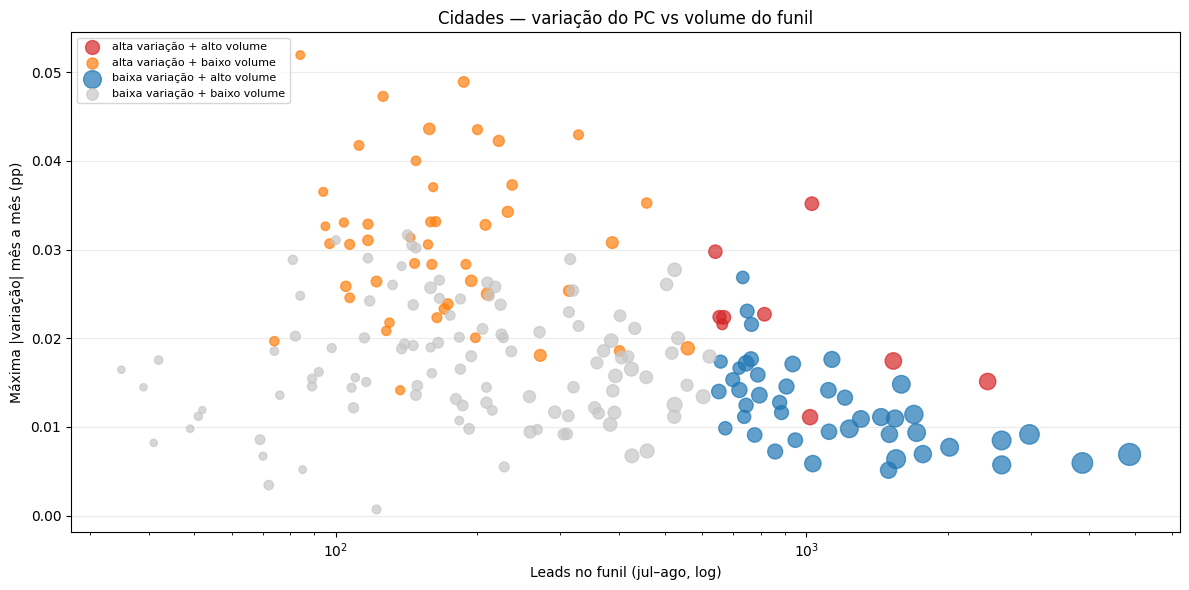

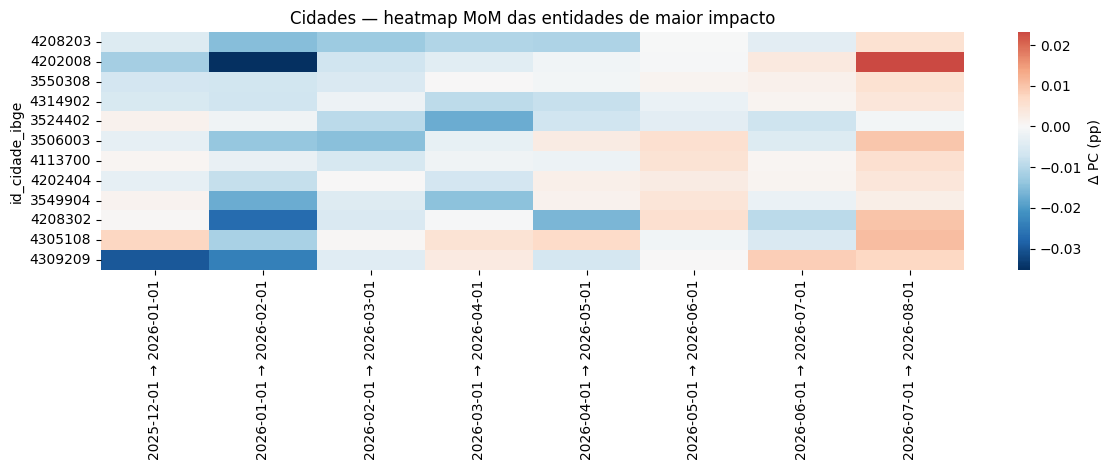

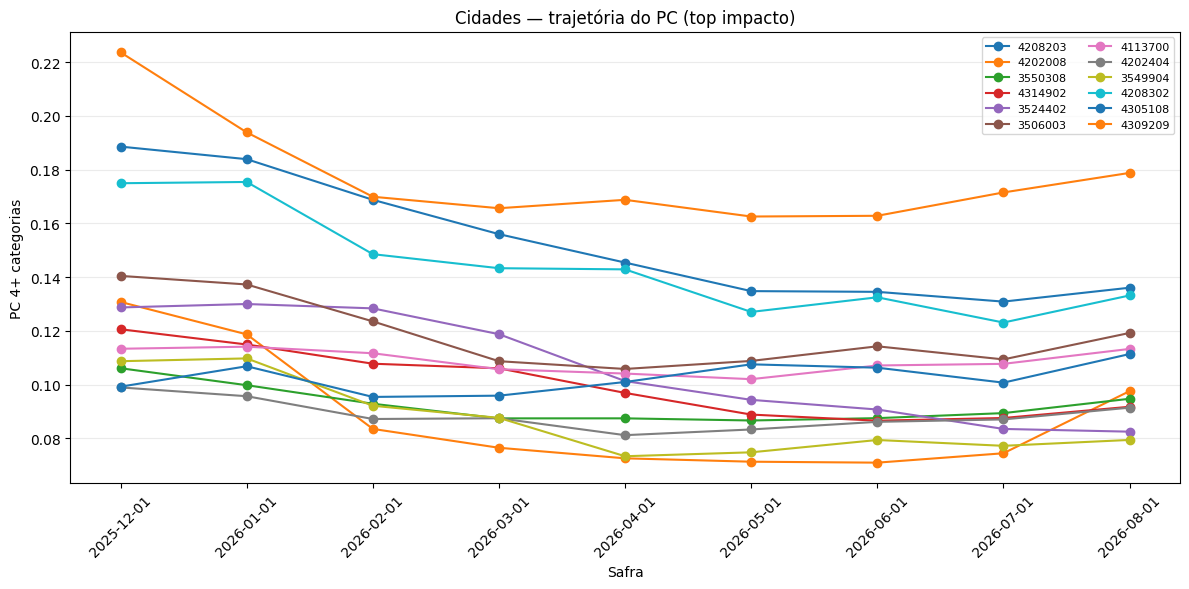

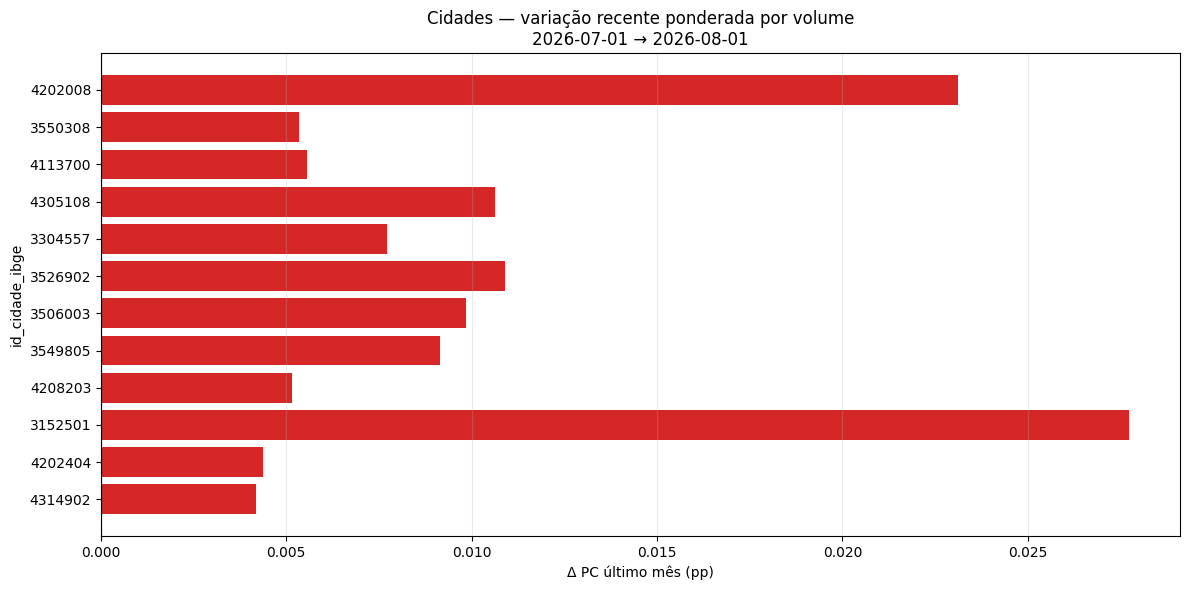

In [104]:
show_priority_tables(city_var, "id_cidade_ibge", "Cidades")
plot_variation_analysis(city_var, city_pc_by_safra, city_pc_mom, "id_cidade_ibge", "Cidades")

### Imobiliárias

Mesma lógica para `agency_pc4_mais_100_contratos__pc_categorias`. Imobs com PC muito volátil e pouco lead tendem a ser ruído; o quadrante vermelho (alta variação + alto volume) é o que concentra risco operacional.

Imobiliárias — cortes e cobertura
  entidades=192 | alta variação=45 | alto volume=48 | prioritárias=8


,quadrante,n_entidades,n_leads,n_ativadas,n_high_var,share_leads,share_ativadas
2,baixa variação + alto volume,40,11800,2651,0,50.7%,44.0%
3,baixa variação + baixo volume,107,7066,2209,0,30.3%,36.6%
1,alta variação + baixo volume,37,2621,842,37,11.3%,14.0%
0,alta variação + alto volume,8,1803,326,8,7.7%,5.4%


Imobiliárias — prioritárias (alta variação + alto volume), top 15 por impacto


,n_safras,pc_first,pc_last,delta_net,pc_std,pc_range,max_abs_mom,last_mom,n_mov_2pp,n_leads,n_ativadas,n_leads_ultimo_mes,tx_proposta,tx_aprovacao,tx_ativacao,share_blend4,impacto,impacto_recente,quadrante,entrou,saiu
agency_id,,,,,,,,,,,,,,,,,,,,,
9118,9,0.344,0.270,-0.074,0.032,0.088,0.039,+0.013,4,290,41,129,30.7%,62.9%,73.2%,27.0%,11.27,1.65,alta variação + alto volume,False,False
3636,9,0.161,0.053,-0.108,0.043,0.121,0.031,-0.005,3,311,42,66,18.0%,80.4%,93.3%,22.2%,9.59,0.35,alta variação + alto volume,False,False
4094,9,0.238,0.138,-0.101,0.040,0.119,0.029,+0.007,4,301,58,117,29.6%,85.4%,76.3%,30.8%,8.70,0.86,alta variação + alto volume,False,False
11913,5,0.200,0.114,-0.086,0.036,0.087,0.050,+0.001,2,156,54,11,82.7%,72.1%,58.1%,8.3%,7.80,0.01,alta variação + alto volume,True,False
1885,6,0.078,0.177,+0.099,0.034,0.099,0.043,+0.020,2,167,33,50,28.7%,83.3%,82.5%,21.5%,7.17,0.99,alta variação + alto volume,True,False
910,5,0.243,0.164,-0.079,0.028,0.079,0.028,—,1,251,27,86,12.7%,90.6%,93.1%,30.7%,7.12,0.00,alta variação + alto volume,False,True
3406,9,0.117,0.161,+0.044,0.026,0.090,0.038,-0.025,3,166,34,58,46.4%,63.6%,69.4%,25.3%,6.28,1.46,alta variação + alto volume,False,False
1207,9,0.211,0.168,-0.043,0.027,0.071,0.033,+0.009,2,161,37,49,29.8%,91.7%,84.1%,24.6%,5.35,0.43,alta variação + alto volume,False,False


Imobiliárias — maiores altas recentes (volume ≥ 86 leads)


,n_safras,pc_first,pc_last,delta_net,pc_std,pc_range,max_abs_mom,last_mom,n_mov_2pp,n_leads,n_ativadas,n_leads_ultimo_mes,tx_proposta,tx_aprovacao,tx_ativacao,share_blend4,impacto,impacto_recente,quadrante,entrou,saiu
agency_id,,,,,,,,,,,,,,,,,,,,,
35054,9,0.151,0.148,-0.004,0.024,0.078,0.044,+0.036,3,187,37,64,34.8%,67.7%,84.1%,24.1%,8.17,2.33,baixa variação + alto volume,False,False
657,9,0.127,0.130,+0.002,0.014,0.048,0.032,+0.031,2,103,39,33,68.9%,63.4%,86.7%,28.0%,3.25,1.04,baixa variação + baixo volume,False,False
1752,9,0.183,0.133,-0.050,0.048,0.145,0.071,+0.027,5,147,20,44,27.2%,60.0%,83.3%,24.1%,10.51,1.20,alta variação + baixo volume,False,False
20503,9,0.079,0.123,+0.044,0.014,0.044,0.026,+0.026,1,119,25,38,41.2%,75.5%,67.6%,34.9%,3.12,1.00,baixa variação + baixo volume,False,False
3037,9,0.204,0.153,-0.050,0.025,0.079,0.029,+0.024,2,151,51,48,57.6%,80.5%,72.9%,25.6%,4.33,1.16,alta variação + baixo volume,False,False
549,9,0.147,0.128,-0.019,0.019,0.054,0.034,+0.023,2,293,84,97,92.2%,90.7%,34.3%,25.3%,10.03,2.19,baixa variação + alto volume,False,False
1695,8,0.096,0.121,+0.025,0.019,0.059,0.029,+0.022,3,171,24,58,19.3%,87.9%,82.8%,25.6%,5.04,1.29,baixa variação + alto volume,True,False
10195,6,0.124,0.185,+0.061,0.019,0.061,0.033,+0.022,2,193,15,73,31.6%,29.5%,83.3%,27.2%,6.39,1.61,baixa variação + alto volume,True,False
1885,6,0.078,0.177,+0.099,0.034,0.099,0.043,+0.020,2,167,33,50,28.7%,83.3%,82.5%,21.5%,7.17,0.99,alta variação + alto volume,True,False


Imobiliárias — maiores quedas recentes (volume ≥ 86 leads)


,n_safras,pc_first,pc_last,delta_net,pc_std,pc_range,max_abs_mom,last_mom,n_mov_2pp,n_leads,n_ativadas,n_leads_ultimo_mes,tx_proposta,tx_aprovacao,tx_ativacao,share_blend4,impacto,impacto_recente,quadrante,entrou,saiu
agency_id,,,,,,,,,,,,,,,,,,,,,
21225,6,0.144,0.083,-0.061,0.025,0.074,0.039,-0.039,2,86,30,19,41.9%,86.1%,96.8%,26.4%,3.38,0.75,baixa variação + baixo volume,True,False
3406,9,0.117,0.161,+0.044,0.026,0.090,0.038,-0.025,3,166,34,58,46.4%,63.6%,69.4%,25.3%,6.28,1.46,alta variação + alto volume,False,False
13704,5,0.196,0.173,-0.023,0.011,0.024,0.024,-0.022,2,148,22,49,29.7%,59.1%,84.6%,28.5%,3.60,1.07,baixa variação + baixo volume,True,False
6558,9,0.055,0.042,-0.013,0.009,0.030,0.019,-0.019,0,103,26,37,47.6%,91.8%,57.8%,28.6%,1.95,0.70,baixa variação + baixo volume,False,False
993,9,0.085,0.096,+0.010,0.016,0.048,0.031,-0.014,2,136,36,29,33.8%,87.0%,90.0%,21.5%,4.25,0.40,baixa variação + baixo volume,False,False
13380,4,0.342,0.342,+0.000,0.006,0.013,0.013,-0.013,0,164,25,73,29.3%,79.2%,65.8%,30.0%,2.19,0.93,baixa variação + alto volume,True,False
13222,5,0.157,0.136,-0.020,0.008,0.020,0.014,-0.013,0,106,13,43,17.0%,83.3%,86.7%,35.9%,1.46,0.54,baixa variação + baixo volume,True,False
40682,9,0.193,0.183,-0.009,0.011,0.034,0.023,-0.012,1,371,22,106,11.9%,63.6%,78.6%,28.8%,8.35,1.26,baixa variação + alto volume,False,False
13554,9,0.224,0.231,+0.006,0.011,0.036,0.013,-0.011,0,114,48,47,56.1%,95.3%,78.7%,29.0%,1.46,0.53,baixa variação + baixo volume,False,False


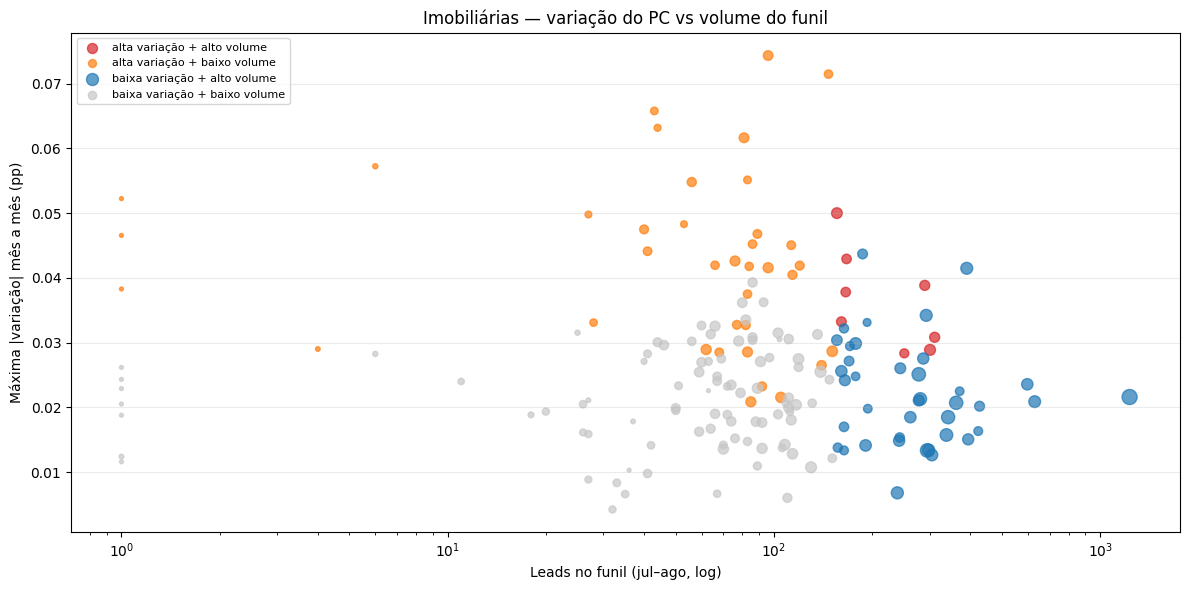

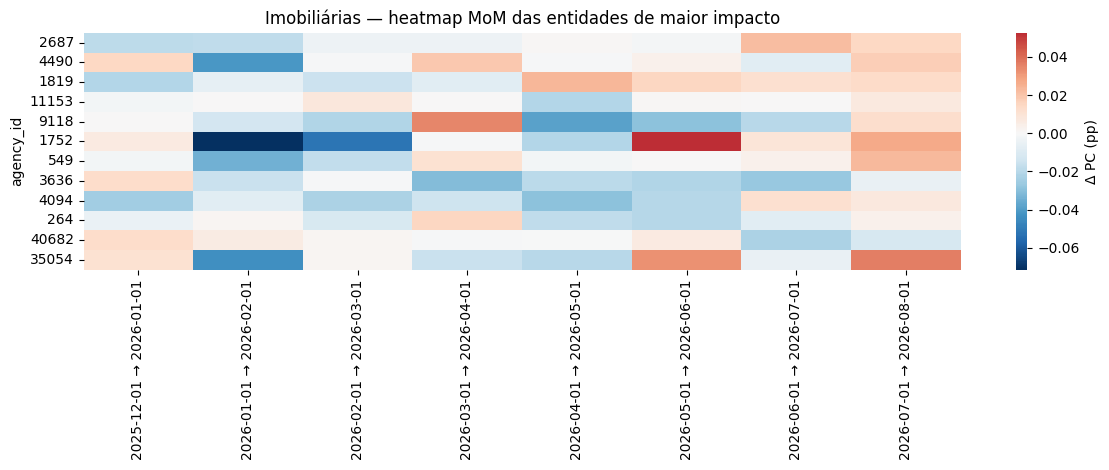

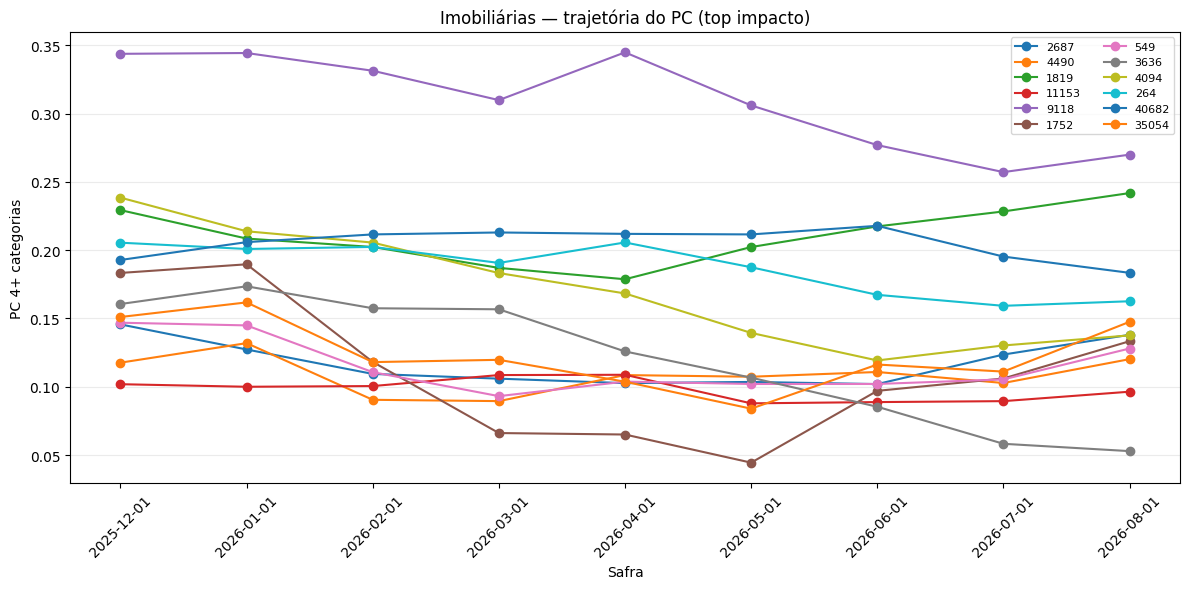

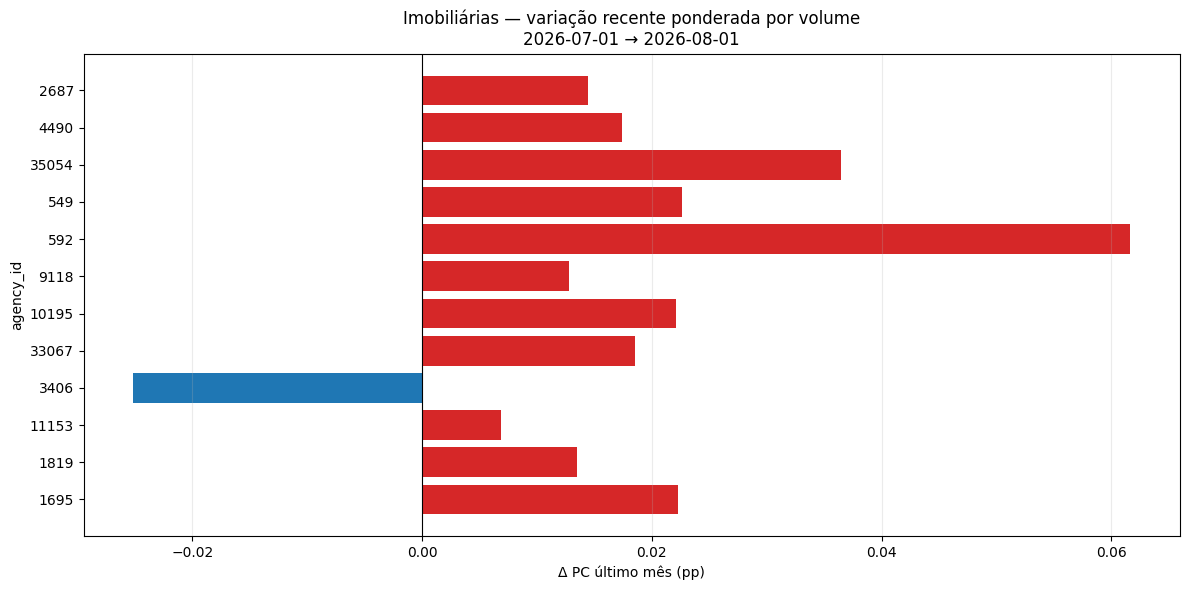

In [105]:
show_priority_tables(agency_var, "agency_id", "Imobiliárias")
plot_variation_analysis(agency_var, agency_pc_by_safra, agency_pc_mom, "agency_id", "Imobiliárias")

### Concentração comparada

Quanto do funil (leads e ativações) está nas entidades de alta variação de PC. Se a fatia for grande, a instabilidade do PC não é pontual — está concentrada em players que movem o mix.

In [106]:
def high_var_share(df: pd.DataFrame, label: str) -> pd.Series:
    high = df["high_var"]
    prio = df["quadrante"] == "alta variação + alto volume"
    leads = df["n_leads"].sum()
    ativ = df["n_ativadas"].sum()
    top10 = df.nlargest(10, "impacto")
    return pd.Series({
        "universo": label,
        "n_entidades": len(df),
        "n_alta_var": int(high.sum()),
        "n_prioritarias": int(prio.sum()),
        "share_entidades_alta_var": high.mean(),
        "share_leads_alta_var": df.loc[high, "n_leads"].sum() / leads if leads else np.nan,
        "share_ativadas_alta_var": df.loc[high, "n_ativadas"].sum() / ativ if ativ else np.nan,
        "share_leads_prioritario": df.loc[prio, "n_leads"].sum() / leads if leads else np.nan,
        "share_ativadas_prioritario": df.loc[prio, "n_ativadas"].sum() / ativ if ativ else np.nan,
        "share_leads_top10_impacto": top10["n_leads"].sum() / leads if leads else np.nan,
        "share_ativadas_top10_impacto": top10["n_ativadas"].sum() / ativ if ativ else np.nan,
        "n_entrou": int(df["entrou"].sum()),
        "n_saiu": int(df["saiu"].sum()),
        "leads_entrou": df.loc[df["entrou"], "n_leads"].sum(),
        "leads_saiu": df.loc[df["saiu"], "n_leads"].sum(),
    })


conc_pc_funil = pd.DataFrame([
    high_var_share(city_var, "Cidades"),
    high_var_share(agency_var, "Imobiliárias"),
])
pct_cols = [c for c in conc_pc_funil.columns if c.startswith("share_")]
display(
    conc_pc_funil.set_index("universo").style.format(
        {c: "{:.1%}" for c in pct_cols} | {"leads_entrou": "{:.0f}", "leads_saiu": "{:.0f}"}
    )
)

print("Cidades que saíram da base de PC e ainda têm volume no funil")
display(
    city_var.loc[city_var["saiu"] & (city_var["n_leads"] > 0)]
    .sort_values("n_leads", ascending=False)
    .set_index("id_cidade_ibge")[["pc_first", "pc_last", "n_leads", "n_ativadas", "last_mom"]]
    .head(15)
)
print("Imobiliárias que saíram da base de PC e ainda têm volume no funil")
display(
    agency_var.loc[agency_var["saiu"] & (agency_var["n_leads"] > 0)]
    .sort_values("n_leads", ascending=False)
    .set_index("agency_id")[["pc_first", "pc_last", "n_leads", "n_ativadas", "last_mom"]]
    .head(15)
)


,n_entidades,n_alta_var,n_prioritarias,share_entidades_alta_var,share_leads_alta_var,share_ativadas_alta_var,share_leads_prioritario,share_ativadas_prioritario,share_leads_top10_impacto,share_ativadas_top10_impacto,n_entrou,n_saiu,leads_entrou,leads_saiu
universo,,,,,,,,,,,,,,
Cidades,211,55,9,26.1%,17.6%,15.7%,9.2%,6.8%,22.3%,18.9%,23,13,3098,1155
Imobiliárias,192,45,8,23.4%,19.0%,19.4%,7.7%,5.4%,19.8%,12.1%,39,34,3049,2882


Cidades que saíram da base de PC e ainda têm volume no funil


,pc_first,pc_last,n_leads,n_ativadas,last_mom
id_cidade_ibge,,,,,
4109807,0.043103,0.054545,184,44,NaN
4313375,0.213592,0.240385,161,25,NaN
3502101,0.171642,0.109091,126,39,NaN
3557006,0.111111,0.116071,110,21,NaN
4307708,0.145631,0.099010,107,39,NaN
3511508,0.059701,0.111111,95,21,NaN
2927408,0.216981,0.064815,84,22,NaN
3501905,0.045802,0.033613,70,15,NaN
2704302,0.140351,0.128440,52,10,NaN


Imobiliárias que saíram da base de PC e ainda têm volume no funil


,pc_first,pc_last,n_leads,n_ativadas,last_mom
agency_id,,,,,
4881,0.061404,0.047619,423,24,NaN
910,0.242857,0.163636,251,27,NaN
11985,0.137931,0.123457,242,66,NaN
2648,0.037594,0.027523,191,72,NaN
902,0.145455,0.182609,170,36,NaN
1156,0.157025,0.150442,151,21,NaN
1607,0.120690,0.078431,111,37,NaN
13335,0.075000,0.121495,109,14,NaN
1145,0.166667,0.166667,99,7,NaN
